In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

### Import the tools

These libraries provide data loading, image preparation, the PyTorch model and training utilities, and plotting. We import them first so every later cell can use the same workflow.

**Why:** Keeping the imports together makes the notebook easier to run from the top and shows which tools the project depends on.

In [35]:
# Set random seeds for reproducibility
torch.manual_seed(42)

### Make results repeatable

This fixes PyTorch's random seed so random operations produce the same results each time.

**Why:** Reproducibility makes experiments easier to compare and debug.

In [36]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Choose the computing device

This selects a GPU when CUDA is available; otherwise it uses the CPU.

**Why:** A GPU can process training batches much faster, while the CPU keeps the notebook usable on any machine.

In [37]:
from pathlib import Path
import pandas as pd

df = pd.read_csv("/content/sample_data/mnist_test.csv")
df.head()

,7,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.658,0.659,0.660,0.661,0.662,0.663,0.664,0.665,0.666,0.667
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Load the image data

This reads the MNIST CSV file into a pandas DataFrame and previews the first rows.

**Why:** We need to inspect the raw labels and pixel columns before preparing them for PyTorch.

In [38]:
df.shape

(9999, 785)

### Check the dataset size

This displays the number of rows and columns in the DataFrame.

**Why:** It confirms how many examples and pixel values are available before splitting the data.

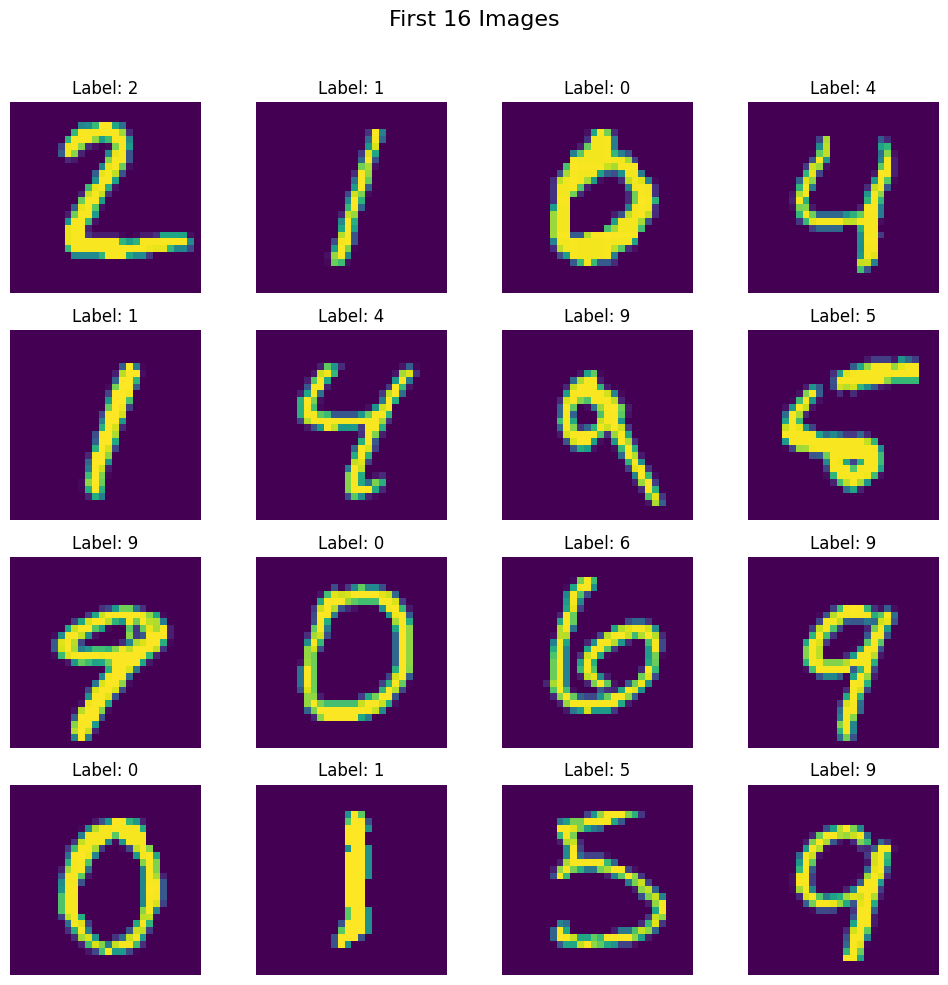

In [39]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


### Visualize sample images

This reshapes the first 16 rows into 28x28 images and displays their labels.

**Why:** Seeing real samples verifies that the pixels and labels were loaded in the expected format.

In [40]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

### Separate features and labels

The first CSV column is the class label, while the remaining columns are flattened pixel values.

**Why:** Models need inputs (`X`) and answers (`y`) stored separately for training.

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Split data for learning and testing

This reserves 80% of the examples for training and 20% for testing.

**Why:** Testing on images the model never saw gives a better estimate of how well it generalizes.

## Image Preprocessing with `Compose`

`Compose` means:

> **Do these transformations one after another.**

The image goes through this pipeline:

**Resize → Crop → Tensor → Normalize**

```text
Original Image
      ↓
   Resize
      ↓
Center Crop
      ↓
  ToTensor
      ↓
 Normalize
      ↓
Ready for CNN

| Step              | What it does                                  |
| ----------------- | --------------------------------------------- |
| `Resize(256)`     | Makes the shorter side 256 pixels             |
| `CenterCrop(224)` | Crops the image to 224 × 224                  |
| `ToTensor()`      | Converts image → PyTorch tensor               |
| `Normalize()`     | Adjusts pixel values for the pretrained model |
| `Compose()`       | Performs all transformations in order         |


In [42]:
# transformations
from torchvision.transforms import transforms

custom_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### Prepare images for VGG16

This pipeline resizes and crops each image, converts it to a tensor, and normalizes its pixel values.

**Why:** A pretrained VGG16 expects 224x224 RGB inputs normalized in the same way as its original training data.

# Custom Dataset in PyTorch

This `CustomDataset` class converts image data stored as NumPy arrays into **PyTorch tensors** that can be used by a CNN.

## Complete Code

```python
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset


class CustomDataset(Dataset):

    def __init__(self, features, labels, transform=None):
        self.features = features
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):

        # 1. Get the image and reshape it to 28 × 28
        image = self.features[index].reshape(28, 28)

        # 2. Convert the image to uint8
        image = image.astype(np.uint8)

        # 3. Convert grayscale image (H, W)
        #    to RGB image (H, W, C)
        image = np.stack([image] * 3, axis=-1)

        # 4. Convert NumPy array to PIL Image
        image = Image.fromarray(image)

        # 5. Apply image transformations
        if self.transform:
            image = self.transform(image)

        # 6. Convert the label to a PyTorch tensor
        label = torch.tensor(
            self.labels[index],
            dtype=torch.long
        )

        # 7. Return image and label
        return image, label
```

---

# Understanding the Code

## 1. Import Libraries

```python
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset
```

We use:

| Library     | Purpose                         |
| ----------- | ------------------------------- |
| `PIL.Image` | Work with images                |
| `numpy`     | Manipulate image arrays         |
| `torch`     | Create PyTorch tensors          |
| `Dataset`   | Create a custom PyTorch dataset |

---

## 2. Create the Dataset Class

```python
class CustomDataset(Dataset):
```

We create our own dataset called `CustomDataset`.

It inherits from PyTorch's `Dataset` class.

```text
PyTorch Dataset
       ↓
CustomDataset
```

This allows PyTorch's `DataLoader` to work with our data.

---

## 3. `__init__()` — Store the Data

```python
def __init__(self, features, labels, transform=None):
    self.features = features
    self.labels = labels
    self.transform = transform
```

The dataset receives three things:

```text
features  → images
labels    → answers/classes
transform → image preprocessing
```

For example:

```text
features → [image1, image2, image3, ...]
labels   → [0, 1, 2, ...]
```

`transform=None` means that using a transform is optional.

---

## 4. `__len__()` — Number of Images

```python
def __len__(self):
    return len(self.features)
```

This tells PyTorch how many images are in the dataset.

For example:

```text
features contains 10,000 images

len(dataset)
      ↓
   10,000
```

---

# 5. `__getitem__()` — Get One Image

```python
def __getitem__(self, index):
```

This function retrieves **one image and its label**.

For example:

```python
dataset[0]
```

means:

> Give me the first image and its label.

---

## Step 1 — Reshape the Image

```python
image = self.features[index].reshape(28, 28)
```

The image may originally be stored as a flat array:

```text
784 values
```

because:

```text
28 × 28 = 784
```

We reshape it:

```text
784
 ↓
28 × 28
```

So the image becomes a 2D image.

---

## Step 2 — Convert to `uint8`

```python
image = image.astype(np.uint8)
```

`uint8` is a common data type for images.

It stores values from:

```text
0 → 255
```

where:

```text
0   = black
255 = white
```

---

## Step 3 — Convert Grayscale to RGB

A grayscale image has only **one channel**:

```text
(H, W)
```

For a `28 × 28` image:

```text
28 × 28
```

But many pretrained CNN models expect **3-channel RGB images**:

```text
(H, W, C)
```

where:

```text
H = Height
W = Width
C = Channels
```

We create three identical channels:

```python
image = np.stack([image] * 3, axis=-1)
```

The shape changes:

```text
Before:

28 × 28

      ↓

After:

28 × 28 × 3
```

The three channels are:

```text
Red
Green
Blue
```

Because the original image is grayscale, the same values are copied into all three channels.

```text
Grayscale
    │
    ├── Red
    ├── Green
    └── Blue
```

---

## Step 4 — Convert NumPy Array to PIL Image

```python
image = Image.fromarray(image)
```

Now we convert:

```text
NumPy array
     ↓
PIL Image
```

This is useful because many `torchvision.transforms` work with PIL images.

---

## Step 5 — Apply Transformations

```python
if self.transform:
    image = self.transform(image)
```

If a transform was provided, it is applied to the image.

For example:

```python
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
```

The image goes through:

```text
PIL Image
    ↓
Resize
    ↓
Center Crop
    ↓
ToTensor
    ↓
Normalize
    ↓
PyTorch Tensor
```

---

## Step 6 — Convert the Label to a Tensor

```python
label = torch.tensor(
    self.labels[index],
    dtype=torch.long
)
```

The label is converted into a PyTorch tensor.

For example:

```text
Original label:

2

      ↓

PyTorch tensor:

tensor(2)
```

`torch.long` is commonly used for class labels in multiclass classification with `CrossEntropyLoss`.

---

# Step 7 — Return Image and Label

```python
return image, label
```

Each time we request an item, we get:

```text
(image, label)
```

For example:

```python
image, label = dataset[0]
```

The result might look like:

```text
image → Tensor with shape [3, 224, 224]
label → tensor(5)
```

---

# Complete Data Flow

The entire process can be remembered like this:

```text
Raw Image
   │
   ▼
Reshape 784 → 28 × 28
   │
   ▼
Convert to uint8
   │
   ▼
Grayscale → RGB
28 × 28 → 28 × 28 × 3
   │
   ▼
NumPy Array → PIL Image
   │
   ▼
Apply Transforms
   │
   ├── Resize
   ├── Crop
   ├── ToTensor
   └── Normalize
   │
   ▼
PyTorch Tensor
   │
   ▼
Return
(image, label)
```

## Easy Memory Trick

Remember the `__getitem__()` process as:

```text
GET IMAGE
   ↓
RESHAPE
   ↓
UINT8
   ↓
RGB
   ↓
PIL
   ↓
TRANSFORM
   ↓
TENSOR LABEL
   ↓
RETURN
```

> **Main idea:** `CustomDataset` acts as a bridge between your raw NumPy image data and the PyTorch CNN. It prepares each image in the format that the neural network expects.


In [43]:
from PIL import Image
import numpy as np

class CustomDataset(Dataset):

  def __init__(self, features, labels, transform):
    self.features = features
    self.labels = labels
    self.transform = transform

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):

    # resize to (28, 28)
    image = self.features[index].reshape(28,28)

    # change datatype to np.uint8
    image = image.astype(np.uint8)

    # change black&white to color -> (H,W,C) -> (C,H,W)
    image = np.stack([image]*3, axis=-1)

    # convert array to PIL image
    image = Image.fromarray(image)

    # apply transforms
    image = self.transform(image)

    # return
    return image, torch.tensor(self.labels[index], dtype=torch.long)

### Build a custom PyTorch dataset

This class converts each flat MNIST row into a 3-channel PIL image, applies the preprocessing pipeline, and returns the image with its label.

**Why:** `Dataset` gives the `DataLoader` a standard way to request individual training examples.

In [44]:
train_dataset = CustomDataset(X_train, y_train, transform=custom_transform)

### Create the training dataset

This connects the training images and labels to `CustomDataset` with the preprocessing transform.

**Why:** The model must receive transformed training examples in PyTorch's dataset format.

In [45]:
test_dataset = CustomDataset(X_test, y_test, transform=custom_transform)

### Create the test dataset

This creates the same dataset format for held-out test images.

**Why:** Evaluation must use the identical preprocessing steps so the model receives compatible inputs.

In [46]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

### Create data loaders

`DataLoader` groups examples into batches of 32; training batches are shuffled, while test batches keep a stable order.

**Why:** Batching makes training efficient and shuffling helps prevent the model from learning the order of the data.

In [47]:
# fetch the pretrained model

import torchvision.models as models

vgg16 = models.vgg16(pretrained=True)

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Load the pretrained VGG16 model

This downloads VGG16 with weights learned from ImageNet.

**Why:** Its convolutional layers already recognize useful visual patterns, so we can reuse them instead of learning every feature from scratch.

In [48]:
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

### Inspect the model

This displays VGG16's architecture, including its feature extractor and classifier.

**Why:** Inspecting the structure helps confirm which part will be frozen and which part will be replaced.

In [49]:
for param in vgg16.features.parameters():
  param.requires_grad=False

### Freeze the pretrained feature extractor

This disables gradient updates for VGG16's convolutional feature layers.

**Why:** The existing visual features are reused, reducing training time and helping prevent overfitting on the smaller MNIST dataset.

In [50]:
vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),

    nn.Linear(4096, 1024),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),

    nn.Linear(1024, 10)
)

### Replace the classifier

This creates a new classifier whose final layer outputs 10 scores, one for each MNIST class.

**Why:** VGG16 originally predicts ImageNet classes, so its final layer must be changed for this classification task.

In [51]:
vgg16 = vgg16.to(device)

### Move the model to the device

This places VGG16 on the selected GPU or CPU.

**Why:** The model and every input batch must be on the same device for PyTorch operations to work.

In [52]:
learning_rate = 0.0001
epochs = 10

### Set training duration

These values choose the learning rate and number of complete passes through the training data.

**Why:** They control how quickly the new classifier learns and how long training runs.

In [53]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(vgg16.parameters(),lr=1e-4,weight_decay=1e-4)

### Choose the loss and optimizer

`CrossEntropyLoss` measures classification mistakes, while AdamW adjusts the trainable weights and applies weight decay.

**Why:** The loss tells the model how wrong it is, and the optimizer uses that signal to improve predictions.

In [54]:
# training loop

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    outputs = vgg16(batch_features)

    print(outputs.shape)
    print(batch_labels.shape)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()
  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


Streaming output truncated to the last 5000 lines.
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32])

### Train the classifier

For each batch, the model predicts classes, the loss is calculated, gradients are computed, and the optimizer updates the trainable weights.

**Why:** Repeating this process over several epochs teaches the new classifier to map MNIST images to the correct class.

In [55]:
vgg16.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

### Switch to evaluation mode

This tells the model that training is finished for the moment.

**Why:** Layers such as dropout behave differently during evaluation, so predictions should use evaluation mode.

In [56]:
# evaluation on test data
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = vgg16(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.982


### Measure test accuracy

This runs the model on unseen test batches without tracking gradients, then compares each prediction with its true label.

**Why:** Test accuracy estimates how well the trained model works on new images and avoids unnecessary gradient memory.

In [57]:
# evaluation on training data
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = vgg16(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9994999374921866


### Measure training accuracy

This calculates accuracy on the examples used during learning.

**Why:** Comparing training accuracy with test accuracy helps reveal whether the model is fitting the data well or overfitting.

In [58]:
torch.save(
    vgg16.state_dict(),
    "vgg16_mnist.pth"
)

print("Model Saved")

Model Saved


### Save the trained weights

This writes the model's learned parameters to a `.pth` file.

**Why:** Saving the weights lets us reuse the trained model later without training it again.

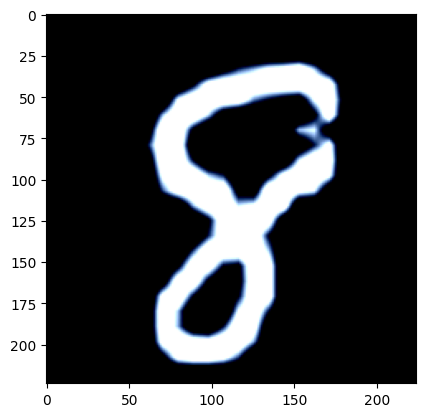

Actual: tensor(8)
Predicted: 8


In [65]:
image, label = test_dataset[90]

plt.imshow(
    image.permute(1,2,0)
)
plt.show()

vgg16.eval()

with torch.no_grad():

    image = image.unsqueeze(0)
    image = image.to(device)

    output = vgg16(image)

    prediction = torch.argmax(output, dim=1)

print("Actual:", label)
print("Predicted:", prediction.item())

### Predict one test image

This selects one transformed test image, adds a batch dimension, and chooses the class with the highest output score.

**Why:** A single example demonstrates the complete inference process and compares the prediction with the real label.

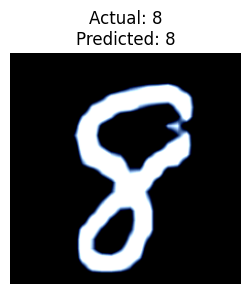

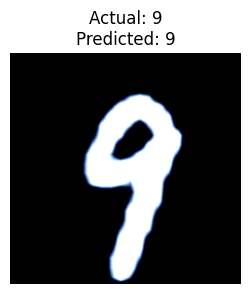

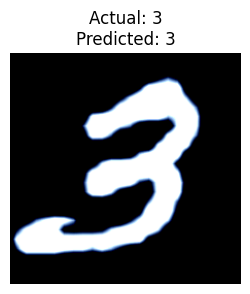

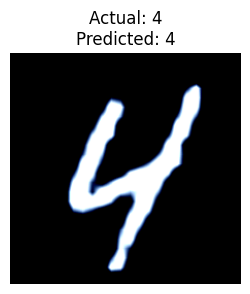

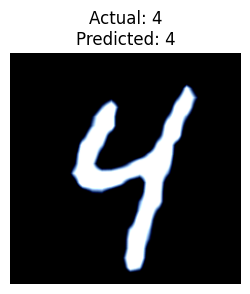

In [67]:
indices = [90, 91, 92, 93, 94]

vgg16.eval()

with torch.no_grad():

    for idx in indices:

        image, label = test_dataset[idx]

        image_input = image.unsqueeze(0).to(device)

        output = vgg16(image_input)

        prediction = torch.argmax(output, dim=1)

        plt.figure(figsize=(3,3))
        plt.imshow(image.permute(1,2,0))
        plt.title(
            f"Actual: {label}\nPredicted: {prediction.item()}"
        )
        plt.axis("off")
        plt.show()

### Compare several predictions

This repeats inference for five test images and plots each image with its actual and predicted class.

**Why:** Looking at several examples gives a more useful qualitative check than inspecting only one prediction.